# Ingestion Dataset

In [2]:
# 1. Instalar kaggle (si ya lo tienes en el env de Anaconda, puedes saltar esto)
!pip install kaggle --quiet

# 2. Apuntar las credenciales a la carpeta del notebook
#    (asegúrate de tener kaggle.json en la misma carpeta donde está el .ipynb)
import os
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()

# 3. Descargar y descomprimir
!kaggle datasets download -d joebeachcapital/dry-beans --unzip -p ./data

Dataset URL: https://www.kaggle.com/datasets/joebeachcapital/dry-beans
License(s): Attribution 4.0 International (CC BY 4.0)




  0%|          | 0.00/4.53M [00:00<?, ?B/s]
 22%|██▏       | 1.00M/4.53M [00:00<00:01, 2.70MB/s]
 44%|████▍     | 2.00M/4.53M [00:00<00:00, 4.75MB/s]
 66%|██████▌   | 3.00M/4.53M [00:00<00:00, 5.69MB/s]
 88%|████████▊ | 4.00M/4.53M [00:00<00:00, 6.42MB/s]
100%|██████████| 4.53M/4.53M [00:00<00:00, 5.71MB/s]


# EDA

In [6]:
from pathlib import Path
import pandas as pd

df = pd.read_excel(r"C:\UAO\Gestion IA y DC\laboratorio_drybean_ml\data\raw\DryBeanDataset\Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
Filas duplicadas: 68
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


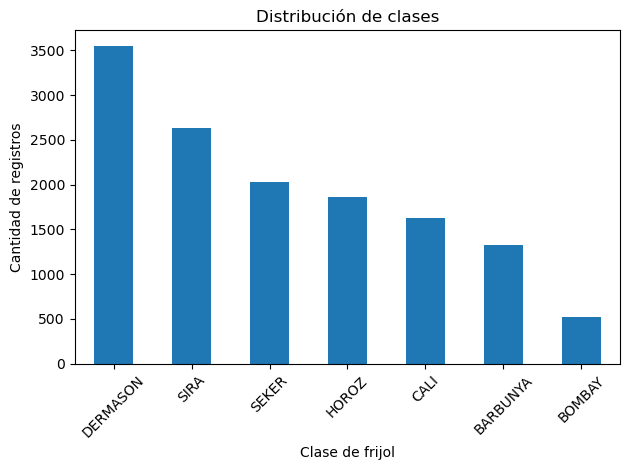

In [8]:
import matplotlib.pyplot as plt

missing_values = df.isna().sum()
duplicated_rows = df.duplicated().sum()
print(missing_values)
print("Filas duplicadas:", duplicated_rows)
df = df.drop_duplicates()

class_counts = df["Class"].value_counts()
print(class_counts)
class_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase de frijol")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X = df.drop(columns="Class")
y = df["Class"]

# Save the model

In [9]:
df.to_csv(r'C:\\UAO\\Gestion IA y DC\\laboratorio_drybean_ml\\data\\processed\\dry_beans_clean.csv', index=False)